# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:** __________NIRALI____________
**Roll Number:** ________AP24110010636______________
**Date:** __________09-10-2026____________

## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [ ]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:*


**Answer:** The 70/30 split has higher entropy than the 90/10 split because its classes are more mixed, making the label harder to guess.

### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [ ]:
parent_entropy = entropy([8, 6])
left_entropy = entropy([6, 0])
right_entropy = entropy([2, 6])
weighted_child_entropy = (6/14) * left_entropy + (8/14) * right_entropy
gain = parent_entropy - weighted_child_entropy
print(f'Parent entropy: {parent_entropy:.4f}')
print(f'Left child entropy: {left_entropy:.4f}')
print(f'Right child entropy: {right_entropy:.4f}')
print(f'Weighted child entropy: {weighted_child_entropy:.4f}')
print(f'Information gain: {gain:.4f}')

Parent entropy: 0.9852
Left child entropy: 0.0000
Right child entropy: 0.8113
Weighted child entropy: 0.4636
Information gain: 0.5216


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [ ]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [ ]:
def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += len(subset) / len(df) * entropy(subset[target].value_counts())
    return total - weighted

print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind)  :', round(info_gain(tennis, 'Wind'), 4))


Root entropy: 0.9403
Gain(Wind)  : 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [ ]:
attributes = ['Outlook', 'Temperature', 'Humidity', 'Wind']
gains = {a: info_gain(tennis, a) for a in attributes}
for a, g in sorted(gains.items(), key=lambda item: item[1], reverse=True):
    print(f'Information gain ({a}): {g:.4f}')
root = max(gains, key=gains.get)
print(f'\\nID3 root: {root}')
for value, subset in tennis.groupby(root):
    print(f'\\n{root} = {value}; Play counts: {subset.Play.value_counts().to_dict()}')
    if subset.Play.nunique() > 1:
        remaining = [a for a in attributes if a != root]
        branch_gains = {a: info_gain(subset, a) for a in remaining}
        for a, g in sorted(branch_gains.items(), key=lambda item: item[1], reverse=True):
            print(f'  Gain ({a}): {g:.4f}')
        print('  Best next split:', max(branch_gains, key=branch_gains.get))

Information gain (Outlook): 0.2467
Information gain (Humidity): 0.1518
Information gain (Wind): 0.0481
Information gain (Temperature): 0.0292
\nID3 root: Outlook
\nOutlook = Overcast; Play counts: {'Yes': 4}
\nOutlook = Rain; Play counts: {'Yes': 3, 'No': 2}
  Gain (Wind): 0.9710
  Gain (Temperature): 0.0200
  Gain (Humidity): 0.0200
  Best next split: Wind
\nOutlook = Sunny; Play counts: {'No': 3, 'Yes': 2}
  Gain (Humidity): 0.9710
  Gain (Temperature): 0.5710
  Gain (Wind): 0.0200
  Best next split: Humidity


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:*


**Answer:** A pure branch contains examples from only one class, so its entropy is zero. Further splitting cannot improve the classification, and the branch can be labeled immediately.

## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


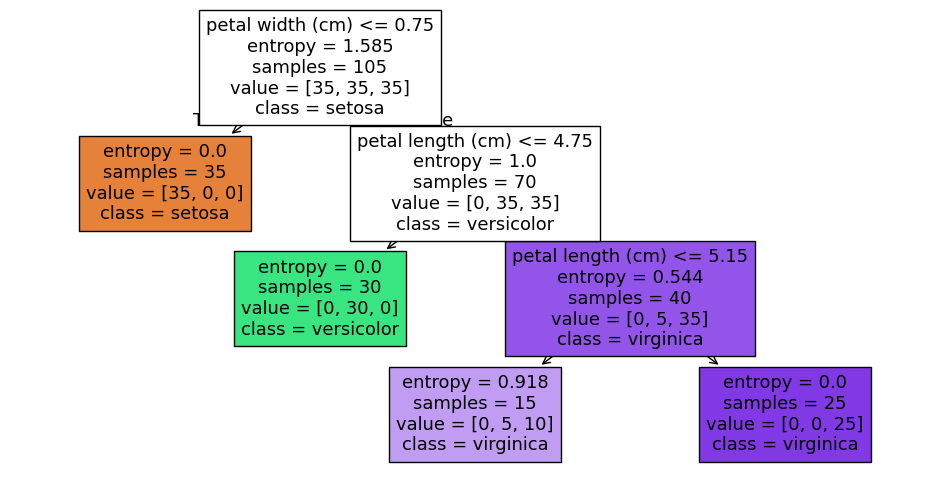

In [ ]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))

plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


,max_depth,train_accuracy,test_accuracy
0,1,0.666667,0.666667
1,2,0.952381,0.955556
2,3,0.952381,0.955556
3,4,0.952381,0.933333
4,5,0.971429,0.977778
5,6,0.980952,0.977778
6,7,0.980952,0.977778
7,8,0.990476,0.977778
8,9,1.000000,0.977778
9,10,1.000000,0.977778


Best test accuracy: 0.9778 at max_depth=5


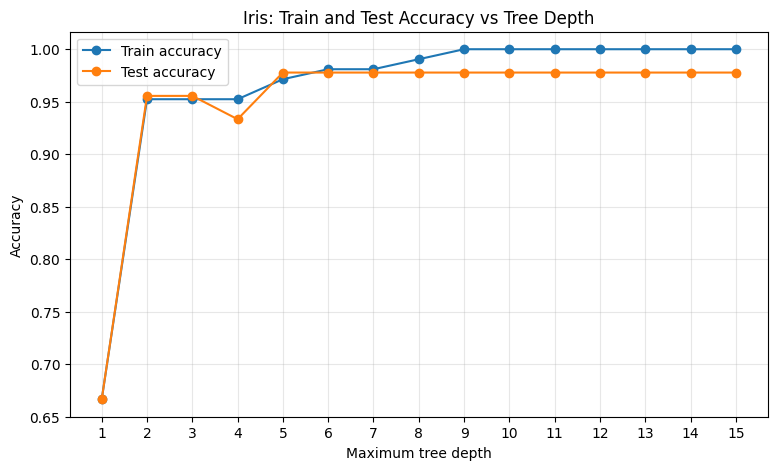

In [ ]:
depth_results = []
for depth in range(1, 16):
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=1)
    model.fit(X_train, y_train)
    depth_results.append({
        'max_depth': depth,
        'train_accuracy': accuracy_score(y_train, model.predict(X_train)),
        'test_accuracy': accuracy_score(y_test, model.predict(X_test))
    })
depth_results_df = pd.DataFrame(depth_results)
display(depth_results_df)
best = depth_results_df.loc[depth_results_df.test_accuracy.idxmax()]
print(f"Best test accuracy: {best.test_accuracy:.4f} at max_depth={int(best.max_depth)}")
plt.figure(figsize=(9, 5))
plt.plot(depth_results_df.max_depth, depth_results_df.train_accuracy, marker='o', label='Train accuracy')
plt.plot(depth_results_df.max_depth, depth_results_df.test_accuracy, marker='o', label='Test accuracy')
plt.xlabel('Maximum tree depth')
plt.ylabel('Accuracy')
plt.title('Iris: Train and Test Accuracy vs Tree Depth')
plt.xticks(range(1, 16))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:*


**Answer:** Polynomial degree in Week 6 and K in KNN in Week 7 play a similar role to tree depth. A shallow tree, low degree, or very large K may underfit; a very deep tree, high degree, or very small K may overfit.

# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [ ]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

# KNN baseline from Week 7 (scaled, K=3)
sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))


KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


Decision tree test accuracy (unscaled): 0.8815
max_depth=3: test accuracy=0.5296
max_depth=6: test accuracy=0.8537
max_depth=10: test accuracy=0.8796


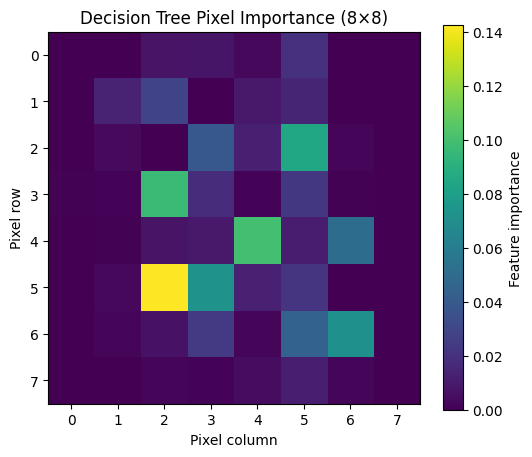

Most important pixels (row, column, importance):
(5, 2, 0.1426)
(4, 4, 0.0997)
(3, 2, 0.0970)
(2, 5, 0.0853)
(5, 3, 0.0727)
(6, 6, 0.0714)
(4, 6, 0.0507)
(6, 5, 0.0449)
(2, 3, 0.0393)
(1, 2, 0.0289)
Best tested depth: 10 (accuracy=0.8796)


In [ ]:
digit_tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
digit_tree.fit(Xd_train, yd_train)
print(f'Decision tree test accuracy (unscaled): {accuracy_score(yd_test, digit_tree.predict(Xd_test)):.4f}')

digit_depth_scores = {}
for depth in [3, 6, 10]:
    model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=1)
    model.fit(Xd_train, yd_train)
    digit_depth_scores[depth] = accuracy_score(yd_test, model.predict(Xd_test))
    print(f'max_depth={depth}: test accuracy={digit_depth_scores[depth]:.4f}')

importance_map = digit_tree.feature_importances_.reshape(8, 8)
plt.figure(figsize=(6, 5))
plt.imshow(importance_map, cmap='viridis')
plt.colorbar(label='Feature importance')
plt.title('Decision Tree Pixel Importance (8×8)')
plt.xlabel('Pixel column')
plt.ylabel('Pixel row')
plt.show()
print('Most important pixels (row, column, importance):')
for idx in np.argsort(digit_tree.feature_importances_)[::-1][:10]:
    print(f'({idx // 8}, {idx % 8}, {digit_tree.feature_importances_[idx]:.4f})')
best_depth = max(digit_depth_scores, key=digit_depth_scores.get)
print(f'Best tested depth: {best_depth} (accuracy={digit_depth_scores[best_depth]:.4f})')

**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:*


**Answer:** The decision tree is generally less accurate than KNN on digits because it uses a sequence of threshold questions and may focus on only a few pixels. KNN compares the full pixel patterns of nearby examples. The importance map shows which pixels the tree relies on most.

# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [ ]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']

vocab = sorted(set(w for s in sentences for w in s.lower().split()))

def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])

X_text = np.array([to_vector(s, vocab) for s in sentences])


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [ ]:
text_tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
text_tree.fit(X_text, labels)
print('Decision tree rules:')
print(export_text(text_tree, feature_names=vocab))

test_sentences = ['the striker scored a goal', 'the phone battery is fast']
test_vectors = np.array([to_vector(s, vocab) for s in test_sentences])
for sentence, prediction in zip(test_sentences, text_tree.predict(test_vectors)):
    print(f'Prediction for {sentence!r}: {prediction}')
print('Training accuracy on six sentences:', accuracy_score(labels, text_tree.predict(X_text)))

Decision tree rules:
|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

Prediction for 'the striker scored a goal': sports
Prediction for 'the phone battery is fast': sports
Training accuracy on six sentences: 1.0


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:*


**Answer:** The split words may change when more sentences are added. With only six examples, the tree can learn accidental patterns and may not generalize well. More varied examples and evaluation on unseen data are needed before trusting it.

## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
